In [15]:
import sys
sys.path.append("../")
import importlib
from functools import partial

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

# import GNNInterpreter
# from GNNInterpreter.gnninterpreter import *
# importlib.reload(GNNInterpreter.gnninterpreter)

# import gnn_xai_common
# from gnn_xai_common import *
# importlib.reload(gnn_xai_common.trainer)

In [16]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cuda"
}

# Data

In [17]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [18]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6315  val_acc=0.632
[002/10] train_loss=0.5257  val_acc=0.632
[003/10] train_loss=0.5339  val_acc=0.632
[004/10] train_loss=0.5260  val_acc=0.632
[005/10] train_loss=0.5116  val_acc=0.632
[006/10] train_loss=0.5183  val_acc=0.632
[007/10] train_loss=0.5045  val_acc=0.632
[008/10] train_loss=0.4858  val_acc=0.632
[009/10] train_loss=0.4937  val_acc=0.632
[010/10] train_loss=0.4785  val_acc=0.632
Test Accuracy: 0.474


# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 752 pairs.


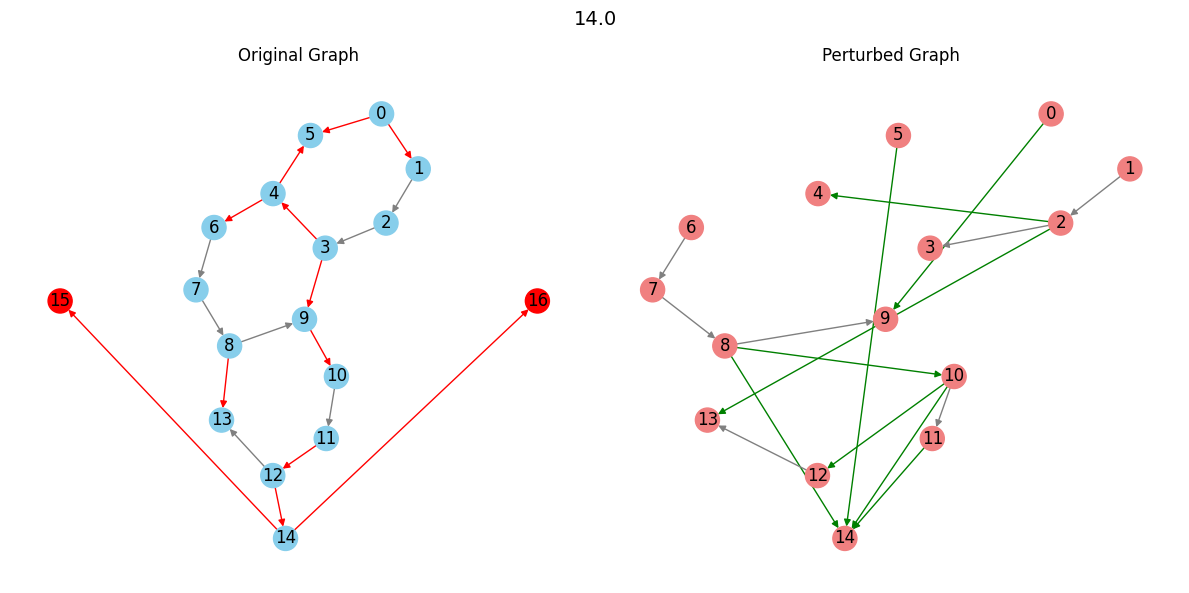

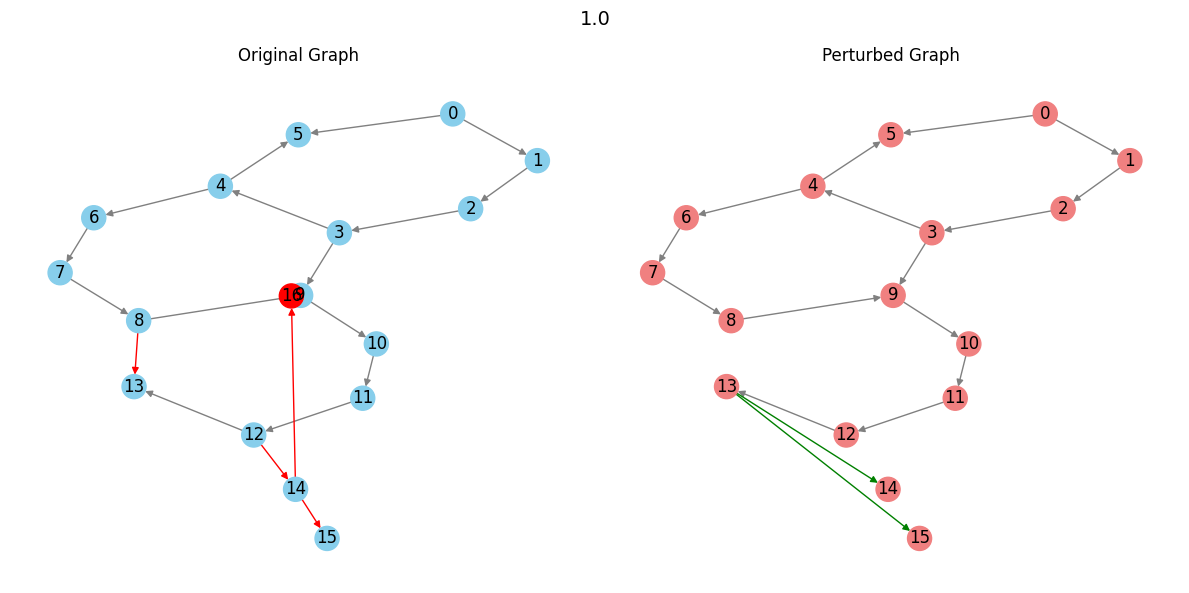

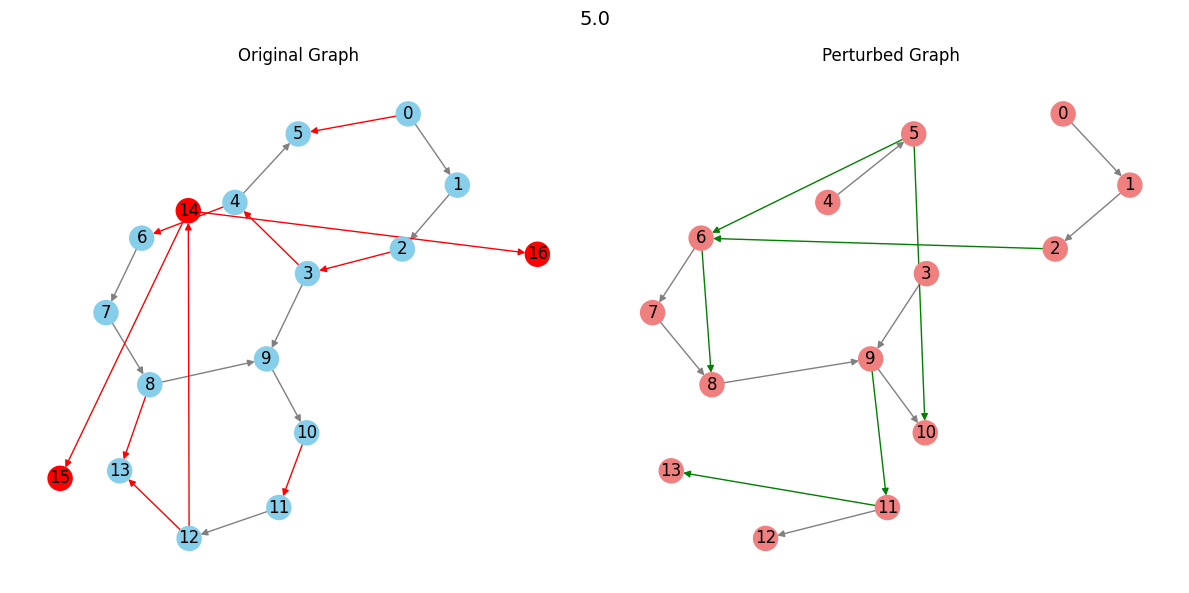

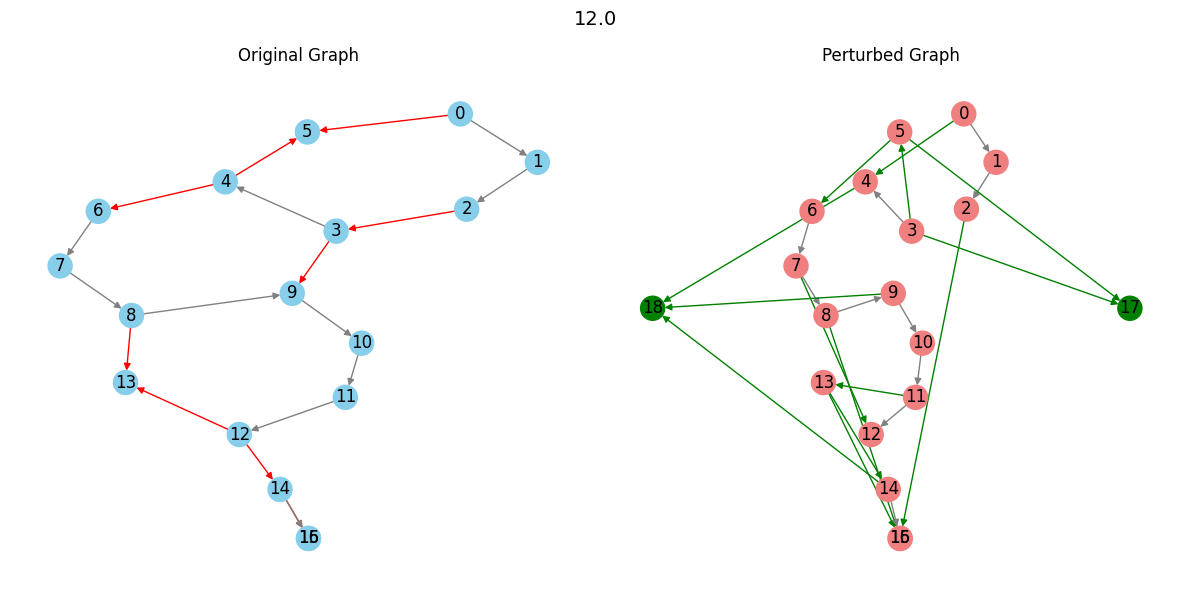

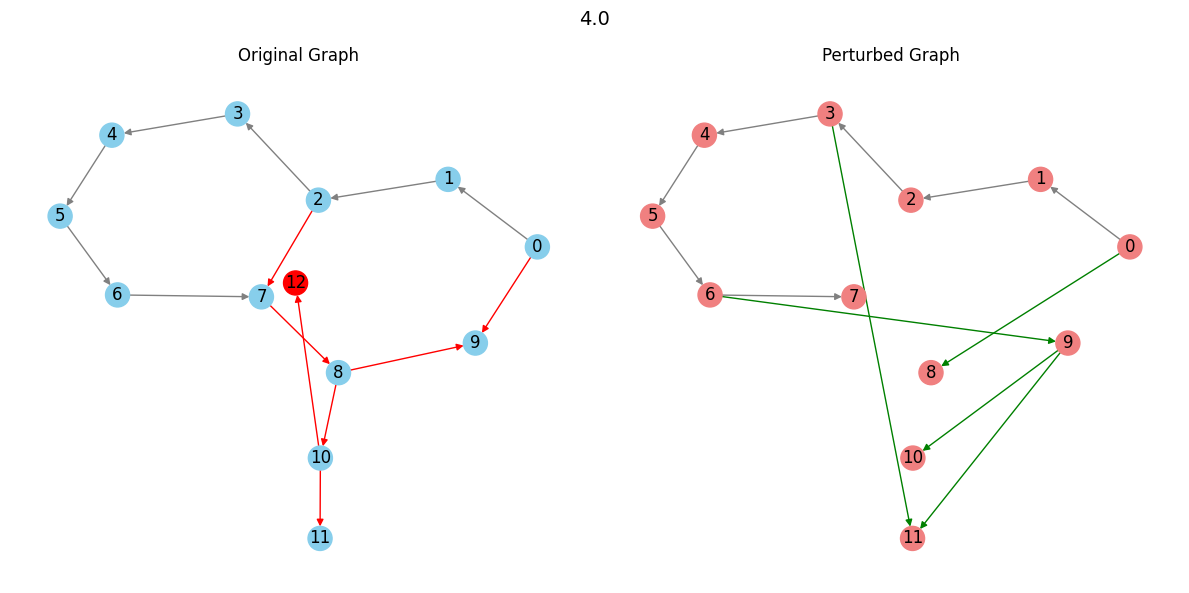

In [19]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=4,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [20]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=64, 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=5, 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.3289 | MSE(norm): 0.3289 | MSE(raw): 176.4716 | Corr(norm): -0.0005 | Corr(raw): 0.1961
Epoch 002 | Loss: 0.1512 | MSE(norm): 0.1512 | MSE(raw): 71.4397 | Corr(norm): 0.1372 | Corr(raw): 0.4756
Epoch 003 | Loss: 0.1392 | MSE(norm): 0.1392 | MSE(raw): 61.0720 | Corr(norm): 0.1323 | Corr(raw): 0.5114
Epoch 004 | Loss: 0.1319 | MSE(norm): 0.1319 | MSE(raw): 59.6739 | Corr(norm): 0.1749 | Corr(raw): 0.5267
Epoch 005 | Loss: 0.1286 | MSE(norm): 0.1286 | MSE(raw): 57.8275 | Corr(norm): 0.2022 | Corr(raw): 0.5615


# Distances

In [41]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import (
    neural_approx_ged_dist, 
    mcs_soft_graph_dist, 
    spectral_dist, 
    wl_graph_kernel_dist
)

nn_GED = neural_approx_ged_dist(
    data, model, explainee, 0
)

max_common_sub = mcs_soft_graph_dist(
    data
)

spectral_dist = spectral_dist(
    data
) 

wl_graph_kernel_dist = wl_graph_kernel_dist(
    data
)

# Generator

In [42]:
import new_src.graph_sampler
import new_src.trainer

from new_src.graph_sampler import GraphSampler
from new_src.trainer import Trainer
from new_src.criteria import (
    WeightedCriterion, 
    ClassScoreCriterion, 
    EmbeddingCriterion, 
    BudgetPenalty
)

def train_generator(
    cls_idx, 
    data, 
    mean_embeds, 
    explainee, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_msc=1,
    w_spec=1,
    w_wl=1,
):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="cont_data", 
                 criterion=nn_GED, 
                 weight=w_ged
            ), 
            dict(key="cont_data", 
                 criterion=max_common_sub, 
                 weight=w_msc
            ), 
            dict(key="cont_data", 
                 criterion=spectral_dist, 
                 weight=w_spec
            ), 
            dict(key="cont_data", 
                 criterion=wl_graph_kernel_dist, 
                 weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=20,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

In [43]:
gen_samples = 2

graphs_0 = []
graphs_1 = []
for i in range(gen_samples): 
    graphs_0.append(train_generator(0, data, mean_embeds, explainee))
    graphs_1.append(train_generator(1, data, mean_embeds, explainee))

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

## Tuning

# Evaluation

In [44]:
import new_src.eval 
importlib.reload(new_src.eval)

from new_src.eval import eval_summary

dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

score = eval_summary(
    explainee, 
    graphs_0,
    graphs_1, 
    cls_split[0], 
    cls_split[1], 
    dist_to_0, 
    dist_to_1
)

Prediction Interval Class 0 0.6273926496505737 +/- 0.001517266035079956

Prediction Interval Class 1 0.44030410051345825 +/- 0.03284148871898651

Counterfactual Shift to Class 0 0.11534328013658524 +/- 0.04078037291765213

Counterfactual Shift to Class 1 -0.025698646903038025 +/- 0.046356793493032455

Class 0 Perturbation Sensitivity 0.004342794418334961 +/- 0.0049249897710978985

Class 1 Perturbation Sensitivity 0.008151468820869923 +/- 0.008083582855761051

Relative Distance to Class 0 0.009096190333366394 +/- 0.026671811938285828 

Relative Distance to Class 1 -0.012912675738334656 +/- 0.026426836848258972 



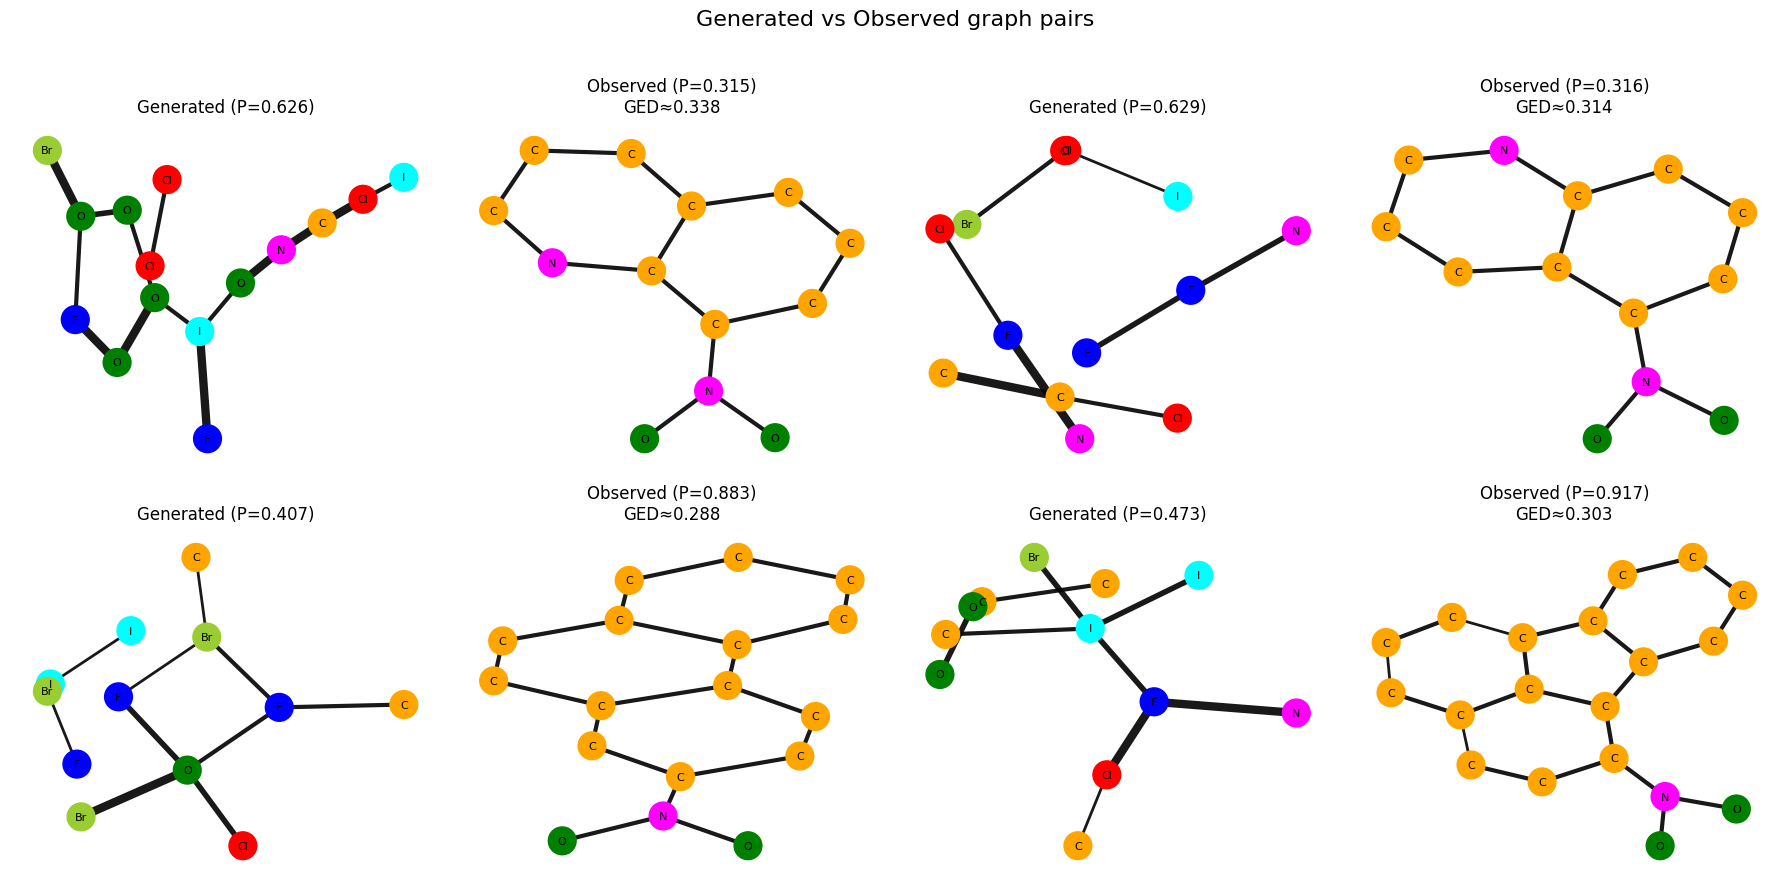

In [45]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)

## Ray Tune Hyperparameter Optimization
We leverage Ray Tune to search for generator loss weights that improve downstream evaluation scores before reporting final results.

In [ ]:
import ray

ray.shutdown()
ray.init(num_gpus=1, runtime_env={"py_modules": ["/repo/revisions/new_src"]})


In [ ]:
explainee_ref = ray.put(explainee)
data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
dist_to_0_ref = ray.put(neural_approx_ged_dist(cls_split[0], model))
dist_to_1_ref = ray.put(neural_approx_ged_dist(cls_split[1], model))


### Define Ray Tune trainable
The trainable recreates required objects from Ray ObjectRefs and evaluates generator outputs for each sampled weight configuration.

In [ ]:
def tune_trainable(config, *, explainee_ref, data_ref, mean_embeds_ref, dist_to_0_ref, dist_to_1_ref, gen_samples=2):
    import ray
    import torch
    import torch.nn.functional as F  # noqa: F401
    from ray import tune
    from new_src.eval import eval_summary
    from __main__ import train_generator

    explainee = ray.get(explainee_ref)
    data = ray.get(data_ref)
    mean_embeds = ray.get(mean_embeds_ref)
    dist_to_0 = ray.get(dist_to_0_ref)
    dist_to_1 = ray.get(dist_to_1_ref)

    cls_split = data.split_by_class()

    pred_weight = config["pred_weight"]
    embed_weight = config["embed_weight"]
    ged_weight = config["ged_weight"]
    mcs_weight = config["mcs_weight"]
    spectral_weight = config["spectral_weight"]
    wl_weight = config["wl_weight"]

    graphs_0 = []
    graphs_1 = []
    for _ in range(gen_samples):
        graphs_0.append(
            train_generator(
                0,
                data,
                mean_embeds,
                explainee,
                w_pred=pred_weight,
                w_embed=embed_weight,
                w_ged=ged_weight,
                w_msc=mcs_weight,
                w_spec=spectral_weight,
                w_wl=wl_weight
            )
        )
        graphs_1.append(
            train_generator(
                1,
                data,
                mean_embeds,
                explainee,
                w_pred=pred_weight,
                w_embed=embed_weight,
                w_ged=ged_weight,
                w_msc=mcs_weight,
                w_spec=spectral_weight,
                w_wl=wl_weight
            )
        )

    score = eval_summary(
        explainee,
        graphs_0,
        graphs_1,
        cls_split[0],
        cls_split[1],
        dist_to_0,
        dist_to_1
    )

    tune.report(score=float(score))


### Configure search space
We explore wide uniform ranges for each generator loss weight to let Ray Tune discover effective trade-offs.

In [ ]:
from ray import tune

search_space = {
    "pred_weight": tune.uniform(0, 50),
    "embed_weight": tune.uniform(0, 50),
    "ged_weight": tune.uniform(0, 50),
    "mcs_weight": tune.uniform(0, 50),
    "spectral_weight": tune.uniform(0, 50),
    "wl_weight": tune.uniform(0, 50)
}

t_trainable = tune.with_parameters(
    tune_trainable,
    explainee_ref=explainee_ref,
    data_ref=data_ref,
    mean_embeds_ref=mean_embeds_ref,
    dist_to_0_ref=dist_to_0_ref,
    dist_to_1_ref=dist_to_1_ref
)
t_trainable = tune.with_resources(t_trainable, {"cpu": 1, "gpu": 1})


### Run Ray Tune search
We launch Ray Tune with a modest sample budget to balance exploration and runtime.

In [ ]:
tuner = tune.Tuner(
    t_trainable,
    param_space=search_space,
    tune_config=tune.TuneConfig(metric="score", mode="max", num_samples=20)
)
results = tuner.fit()
results


### Summarize Ray Tune results
We inspect the best configuration and visualize score trajectories before moving to downstream reporting.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

best_config = results.get_best_result().config
print("Best Ray Tune configuration:")
print(best_config)

df = results.get_dataframe()
display(df)

fig, ax = plt.subplots(figsize=(8, 4))
df_sorted = df.sort_values("trial_id")
x_positions = range(len(df_sorted))
ax.plot(x_positions, df_sorted["score"], marker="o")
ax.set_title("Ray Tune score across trials")
ax.set_xlabel("Trial ID")
ax.set_ylabel("Score")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(df_sorted["trial_id"], rotation=45)
plt.tight_layout()
plt.show()


# GNNInterpreter